In [1]:
!pip install qiskit[visualization]
!pip install qiskit-aer
!pip install qiskit-ibm-runtime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 33.3 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=f10099d82a053b375ec9e57ee586ba363bc219702ce36b41da5bf8abc6857cb9
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 104.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.5/378.5 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!pip install matplotlib pylatexenc

In [36]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorSampler, StatevectorEstimator
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp

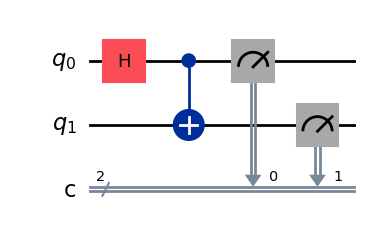

In [4]:
#creating the circuit
qr=QuantumRegister(2,'q')
cr=ClassicalRegister(2,'c')
qc=QuantumCircuit(qr,cr)

qc.h(qr[0])
qc.cx(qr[0],qr[1])   #qr[0]-control, qr[1]-target
# qc.measure_all()
qc.measure([qr[0],qr[1]], [cr[0],cr[1]])
qc.draw(output='mpl')
# qc.draw()


In [5]:
#Choose simulators and primitives
simulator=AerSimulator()
sampler = StatevectorSampler()

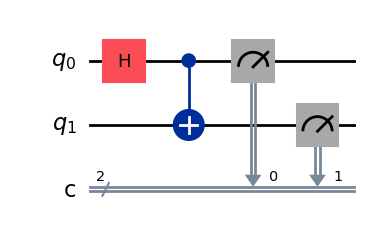

In [16]:
#Creating another circuit
#creating the circuit
qr0=QuantumRegister(2,'q')
cr0=ClassicalRegister(2,'c')
qc1=QuantumCircuit(qr0,cr0)

qc1.h(qr0[0])
qc1.cx(qr0[0],qr0[1])   #qr[0]-control, qr[1]-target
# qc.measure_all()
qc1.measure([qr0[0],qr0[1]], [cr0[0],cr0[1]])
qc1.draw(output='mpl')
# qc.draw()

In [18]:
#run on simulator
job_sim = simulator.run(qc, shots =1024)

#run on sampler
job_sam = sampler.run(([qc], [qc1]), shots =1024)
#list [qc] is called PUB (primitive unified block)-data structure
#which contains quantum circuit, observables, parameters and precision (how much error can be allowed)

Results: Simulator

In [19]:
#get the results of the Simulator
result_sim = job_sim.result()
#get the counts of the Simulator
counts_sim = result_sim.get_counts()
print(counts_sim)

{'00': 516, '11': 508}


Results: Sampler

In [8]:
# #get the results from sampler
# result_sam = job_sam.result()
# #get the counts from sampler
# counts_sam = result_sam.get_counts()

In [20]:
result_sam = job_sam.result()
result_sam

PrimitiveResult([SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=1024, num_bits=2>)), metadata={'shots': 1024, 'circuit_metadata': {}}), SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=1024, num_bits=2>)), metadata={'shots': 1024, 'circuit_metadata': {}})], metadata={'version': 2})

In [21]:
result_sam[0].data.c.get_counts()

{'11': 521, '00': 503}

# create circuit with Parameter

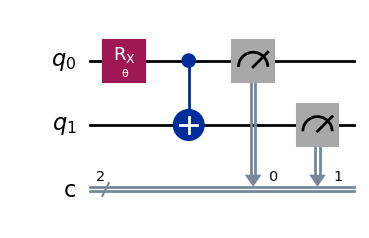

In [11]:
qr=QuantumRegister(2,'q')
cr=ClassicalRegister(2,'c')
pqc=QuantumCircuit(qr,cr)

θ = Parameter('θ')

pqc.rx(θ, qr[0])
pqc.cx(qr[0],qr[1])
pqc.measure([qr[0],qr[1]], [cr[0],cr[1]])

pqc.draw(output='mpl')


In [12]:
angles = [0, pi/2, pi, 3*pi/2]

circuits = []
for angle in angles:
  pqc_t = pqc.assign_parameters({θ: angle})
  circuits.append(pqc_t)

print(circuits)

[<qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7fb82ca326c0>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7fb82ca33800>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7fb82cb4b500>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7fb82ca31eb0>]


circuit 1: 0


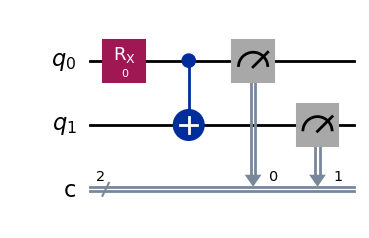

circuit 2: 1.5707963267948966


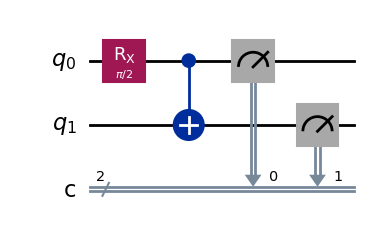

circuit 3: 3.141592653589793


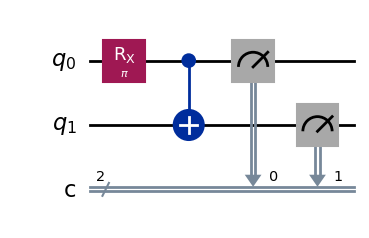

circuit 4: 4.71238898038469


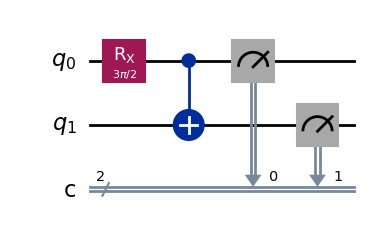

In [13]:
for i, circ in enumerate(circuits):
  #i-index, circ=quantum circuit
  print(f'circuit {i+1}:', angles[i])
  display(circ.draw(output='mpl'))


In [22]:
#circuits are ready. transpile and run results
#simulator
job_sim_trans = transpile(circuits, backend=simulator)
result_sim_trans = simulator.run(job_sim_trans, shots =1000).result()
counts_sim_trans = result_sim_trans.get_counts()
print(counts_sim_trans)


[{'00': 1000}, {'00': 494, '11': 506}, {'11': 1000}, {'00': 511, '11': 489}]


In [30]:
#run sampler for pqc
pqc_results=[]
for i, circ in enumerate(circuits):
  #i-index, circ=quantum circuit
  result_sampler_p=sampler.run([circ], shots=1000).result()
  counts_sampler=result_sampler_p[0].data.c.get_counts()
  print(result_sampler_p)

  pqc_results.append(counts_sampler)

print(pqc_results)



PrimitiveResult([SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=1000, num_bits=2>)), metadata={'shots': 1000, 'circuit_metadata': {}})], metadata={'version': 2})
PrimitiveResult([SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=1000, num_bits=2>)), metadata={'shots': 1000, 'circuit_metadata': {}})], metadata={'version': 2})
PrimitiveResult([SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=1000, num_bits=2>)), metadata={'shots': 1000, 'circuit_metadata': {}})], metadata={'version': 2})
PrimitiveResult([SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=1000, num_bits=2>)), metadata={'shots': 1000, 'circuit_metadata': {}})], metadata={'version': 2})
[{'00': 1000}, {'00': 504, '11': 496}, {'11': 1000}, {'00': 521, '11': 479}]


Estimator

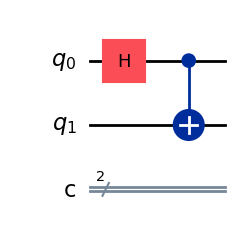

In [39]:
#creating the circuit
qr=QuantumRegister(2,'q')
cr=ClassicalRegister(2,'c')
qce=QuantumCircuit(qr,cr)

qce.h(qr[0])
qce.cx(qr[0],qr[1])   #qr[0]-control, qr[1]-target
# qc.measure_all()
# qc.measure([qr[0],qr[1]], [cr[0],cr[1]])
qce.draw(output='mpl')
# qc.draw()

In [43]:
Observable1= [SparsePauliOp(["XX", "ZZ"], [0.5, 0.5])]
Observable2= [SparsePauliOp(["XX"], [1])]

In [63]:
observables = [Observable1, Observable2]

In [42]:
estimator = StatevectorEstimator()

In [59]:
pub1=(qce, Observable1)
pub2=(qce, Observable2)
publist = [pub1, pub2]

In [67]:
result_estimator_o = estimator.run([(qce, observables)], precision=0.1).result()

In [68]:
result_estimator_o

PrimitiveResult([PubResult(data=DataBin(evs=np.ndarray(<shape=(2, 1), dtype=float64>), stds=np.ndarray(<shape=(2, 1), dtype=float64>), shape=(2, 1)), metadata={'target_precision': 0.1, 'circuit_metadata': {}})], metadata={'version': 2})

In [69]:
result_estimator_o[0]

PubResult(data=DataBin(evs=np.ndarray(<shape=(2, 1), dtype=float64>), stds=np.ndarray(<shape=(2, 1), dtype=float64>), shape=(2, 1)), metadata={'target_precision': 0.1, 'circuit_metadata': {}})

In [70]:
result_estimator_o[0].data.evs

array([[0.96653766],
       [1.0837631 ]])

In [54]:
result_estimator

PrimitiveResult([PubResult(data=DataBin(evs=np.ndarray(<shape=(1,), dtype=float64>), stds=np.ndarray(<shape=(1,), dtype=float64>), shape=(1,)), metadata={'target_precision': 0.0, 'circuit_metadata': {}}), PubResult(data=DataBin(evs=np.ndarray(<shape=(1,), dtype=float64>), stds=np.ndarray(<shape=(1,), dtype=float64>), shape=(1,)), metadata={'target_precision': 0.0, 'circuit_metadata': {}})], metadata={'version': 2})

In [61]:
result_estimator[0].data.evs

array([1.07197383])

In [62]:
result_estimator[1].data.evs

array([1.15093384])